# Spacy me Toknization is tarike se hota hai

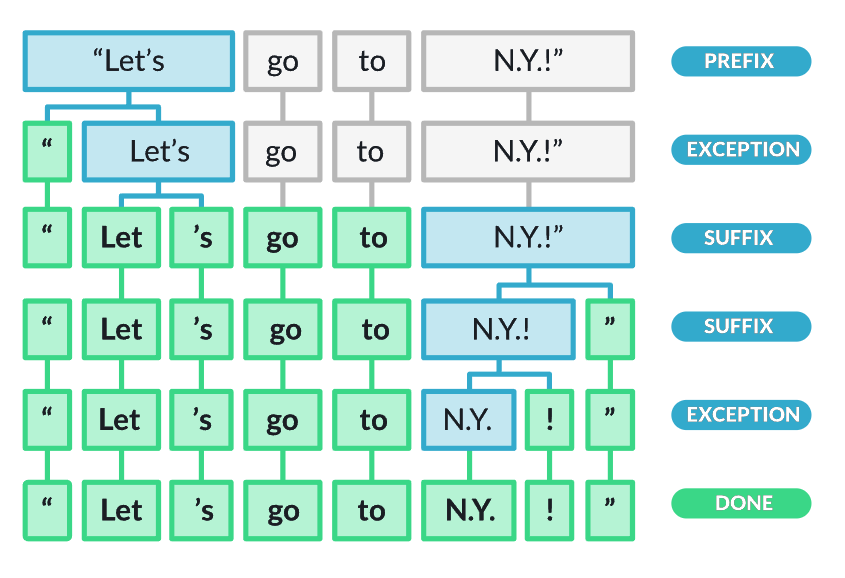



In [73]:
!pip install spacy


In [74]:
import spacy

**Yaha pe nlp ek object pipline hai jis me english ke word hai**

In [75]:
nlp = spacy.blank('en')


In [76]:
doc = nlp("Dr. String loves pav bhaji of mumbai as it costs only 2$ per plate.")
for token in doc:
  print(token)

Dr.
String
loves
pav
bhaji
of
mumbai
as
it
costs
only
2
$
per
plate
.


Creating blank language object gives a tokenizer and an empty pipeline. We will look more into language pipelines in next tutorial
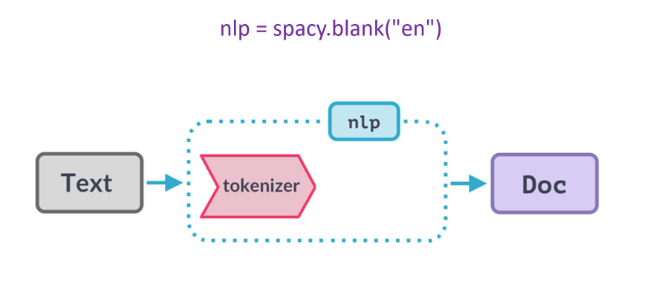



# Using index to grab tokens

In [77]:
doc[0]

Dr.

In [78]:
dir(doc[0])

['_',
 '__bytes__',
 '__class__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__ne__',
 '__new__',
 '__pyx_vtable__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__unicode__',
 'ancestors',
 'check_flag',
 'children',
 'cluster',
 'conjuncts',
 'dep',
 'dep_',
 'doc',
 'ent_id',
 'ent_id_',
 'ent_iob',
 'ent_iob_',
 'ent_kb_id',
 'ent_kb_id_',
 'ent_type',
 'ent_type_',
 'get_extension',
 'has_dep',
 'has_extension',
 'has_head',
 'has_morph',
 'has_vector',
 'head',
 'i',
 'idx',
 'iob_strings',
 'is_alpha',
 'is_ancestor',
 'is_ascii',
 'is_bracket',
 'is_currency',
 'is_digit',
 'is_left_punct',
 'is_lower',
 'is_oov',
 'is_punct',
 'is_quote',
 'is_right_punct',
 'is_sent_end',
 'is_sent_start',
 'is_space',
 'is_stop',
 'is_title',
 'is_upper',
 'lang

In [79]:
type(nlp)

spacy.lang.en.English

In [80]:

type(doc)

spacy.tokens.doc.Doc

In [81]:
nlp.pipe_names

[]

# Span object

In [82]:
span = doc[:5]
span

Dr. String loves pav bhaji

In [83]:
type(span)

spacy.tokens.span.Span

# Token attributes

In [84]:
doc = nlp("Tony gave two $ to Peter.")

In [85]:
token0 = doc[0]
token0

Tony

In [86]:
token0.is_alpha

True

In [87]:
token0.like_num

False

In [88]:
token2 = doc[2]
token2

two

In [89]:
token2.like_num

True

In [90]:
token3 = doc[3]
token3

$

In [91]:
token.like_num

False

In [92]:
token3.is_currency

True

In [93]:
for token in doc:
    print(token, "==>", "index: ", token.i,
          "is_alpha:", token.is_alpha,
          "is_punct:", token.is_punct,
          "like_num:", token.like_num,
          "is_currency:", token.is_currency,
         )

Tony ==> index:  0 is_alpha: True is_punct: False like_num: False is_currency: False
gave ==> index:  1 is_alpha: True is_punct: False like_num: False is_currency: False
two ==> index:  2 is_alpha: True is_punct: False like_num: True is_currency: False
$ ==> index:  3 is_alpha: False is_punct: False like_num: False is_currency: True
to ==> index:  4 is_alpha: True is_punct: False like_num: False is_currency: False
Peter ==> index:  5 is_alpha: True is_punct: False like_num: False is_currency: False
. ==> index:  6 is_alpha: False is_punct: True like_num: False is_currency: False


# **Collecting email ids of students from students information sheet**

In [95]:
with open("/content/drive/MyDrive/NLP Notes/MY NLP/1. Text Preprocessing in NLP/Toknization /students.txt") as f:
    text = f.readlines()
text

['Dayton high school, 8th grade students information\n',
 '==================================================\n',
 '\n',
 'Name\tbirth day   \temail\n',
 '-----\t------------\t------\n',
 'Virat   5 June, 1882    virat@kohli.com\n',
 'Maria\t12 April, 2001  maria@sharapova.com\n',
 'Serena  24 June, 1998   serena@williams.com \n',
 'Joe      1 May, 1997    joe@root.com\n',
 '\n',
 '\n',
 '\n']

In [96]:
text = " ".join(text)
text

'Dayton high school, 8th grade students information\n ==================================================\n \n Name\tbirth day   \temail\n -----\t------------\t------\n Virat   5 June, 1882    virat@kohli.com\n Maria\t12 April, 2001  maria@sharapova.com\n Serena  24 June, 1998   serena@williams.com \n Joe      1 May, 1997    joe@root.com\n \n \n \n'

In [97]:
doc = nlp(text)
emails = []
for token in doc:
    if token.like_email:
        emails.append(token.text)
emails


['virat@kohli.com',
 'maria@sharapova.com',
 'serena@williams.com',
 'joe@root.com']

# Support in other languages
Spacy support many language models. Some of them do not support pipelines though! https://spacy.io/usage/models#languages

In [98]:
nlp = spacy.blank("hi")
doc = nlp("भैया जी! 5000 ₹ उधार थे वो वापस देदो")
for token in doc:
    print(token, token.is_currency)

भैया False
जी False
! False
5000 False
₹ True
उधार False
थे False
वो False
वापस False
देदो False


# **Costumize** **Toknizer**

In [99]:
doc = nlp("gimme double cheese extra large healthy pizza")

tokens = [token.text for token in doc]
tokens

['gimme', 'double', 'cheese', 'extra', 'large', 'healthy', 'pizza']

In [100]:
from spacy.symbols import ORTH

In [101]:
nlp.tokenizer.add_special_case("gimme",[
                               {ORTH : "Give"},
                               {ORTH : "me"}
                               ])
doc = nlp("gimme double cheese extra large healthy pizza")
tokens = [token.text for token in doc]
tokens

ValueError: [E997] Tokenizer special cases are not allowed to modify the text. This would map 'gimme' to 'Giveme' given token attributes '[{65: 'Give'}, {65: 'me'}]'.

## **Note**:-  
 **ValueError: [E997] Tokenizer special cases are not allowed to modify the text. This would map 'gimme' to 'Giveme' given token attributes '[{65: 'Give'}, {65: 'me'}]'.
Hai is ko gim me ke form me kar sakte hai**

In [102]:
nlp.tokenizer.add_special_case("gimme", [
    {ORTH: "gim"},
    {ORTH: "me"}
])
doc = nlp("gimme double cheese extra large healthy pizza")
tokens = [token.text for token in doc]
tokens

['gim', 'me', 'double', 'cheese', 'extra', 'large', 'healthy', 'pizza']

# **Sentance Tokenization**

In [103]:
doc = nlp("Dr. Strange loves pav bhaji of mumbai. Hulk loves chat of delhi")
for sentence in doc.sents:
    print(sentence)

ValueError: [E030] Sentence boundaries unset. You can add the 'sentencizer' component to the pipeline with: `nlp.add_pipe('sentencizer')`. Alternatively, add the dependency parser or sentence recognizer, or set sentence boundaries by setting `doc[i].is_sent_start`.

In [104]:
nlp.add_pipe('sentencizer')

In [105]:
nlp.pipe_names

['sentencizer']

In [106]:
doc = nlp("Dr. Strange loves pav bhaji of mumbai. Hulk loves chat of delhi")
for sentence in doc.sents:
    print(sentence)

Dr.
Strange loves pav bhaji of mumbai.
Hulk loves chat of delhi


In [107]:
doc = nlp("Dr. Strange loves pav bhaji of mumbai. Hulk loves chat of delhi")
for sentence in doc.sents:
    print(sentence)

Dr.
Strange loves pav bhaji of mumbai.
Hulk loves chat of delhi


**Ye tab ho raha hai jab mai proper pip line use kar raha hu nlp ki na ki blank aor na hi koi pip line add kar raha hu faltu ki**

In [108]:
nlp = spacy.load("en_core_web_sm")
doc = nlp("Dr. Strange loves pav bhaji of mumbai. Hulk loves chat of delhi")
for sentence in doc.sents:
    print(sentence)

Dr. Strange loves pav bhaji of mumbai.
Hulk loves chat of delhi


# Exercise
(1) Think stats is a free book to study statistics (https://greenteapress.com/thinkstats2/thinkstats2.pdf)

This book has references to many websites from where you can download free datasets. You are an NLP engineer working for some company and you want to collect all dataset websites from this book. To keep exercise simple you are given a paragraph from this book and you want to grab all urls from this paragraph using spacy

In [111]:
text='''
Look for data to help you address the question. Governments are good
sources because data from public research is often freely available. Good
places to start include http://www.data.gov/, and http://www.science.
gov/, and in the United Kingdom, http://data.gov.uk/.
Two of my favorite data sets are the General Social Survey at http://www3.norc.org/gss+website/,
and the European Social Survey at http://www.europeansocialsurvey.org/.
'''

# TODO: Write code here
# Hint: token has an attribute that can be used to detect a url'

import spacy

nlp = spacy.load("en_core_web_sm")

doc = nlp(text)
urls = []

for token in doc:
    if token.like_url:
        urls.append(token.text)

print(urls)


['http://www.data.gov/', 'http://www.science', 'http://data.gov.uk/.', 'http://www3.norc.org/gss+website/', 'http://www.europeansocialsurvey.org/.']


(2) Extract all money transaction from below sentence along with currency. Output should be,

two $

500 €

In [ ]:
transactions = "Tony gave two $ to Peter, Bruce gave 500 € to Steve"

# TODO: Write code here
# Hint: Use token.i for the index of a token and token.is_currency for currency symbol detection